# Week 2 - Exploratory Data Analysis: Uncovering Customer Spending & Campaign Patterns

**Dataset:** marketing_campaign_cleaned.csv (output of Week 1)

**Goal:** Explore the cleaned data to find patterns worth reporting - compute descriptive stats, build 5+ visualizations, and write down the insight each chart reveals.

In [ ]:
# Step 1 - Loading the cleaned data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('marketing_campaign_cleaned.csv')

print("Shape:", df.shape)
df.head()

In [ ]:
import os
print(os.getcwd())

In [2]:
df = pd.read_csv(r'C:\Users\shiva\Downloads\marketing_campaign_cleaned.csv')

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_Spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,1,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,0,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,0,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,0,30,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,0,33,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,0,47,1341
2233,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,0,68,444
2234,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,0,33,1241
2235,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,0,58,843


In [4]:
# Step 2 - Descriptive statistics

df[['Age','Income','Total_Spend','Recency']].describe()

,Age,Income,Total_Spend,Recency
count,2237.000000,2237.000000,2237.000000,2237.000000
mean,45.098346,52227.407689,605.743406,49.104604
std,11.701917,25043.266830,601.840466,28.956073
min,18.000000,1730.000000,5.000000,0.000000
25%,37.000000,35523.000000,69.000000,24.000000
50%,44.000000,51381.500000,396.000000,49.000000
75%,55.000000,68281.000000,1045.000000,74.000000
max,74.000000,666666.000000,2525.000000,99.000000


# Creating Visualisations

In [25]:
# Step 3 - Create a visualization-safe copy (excludes the outlier)

df_viz = df[df['Income'] < 200000].copy()
print(f"Rows excluded from visuals only: {len(df) - len(df_viz)}")

Rows excluded from visuals only: 1


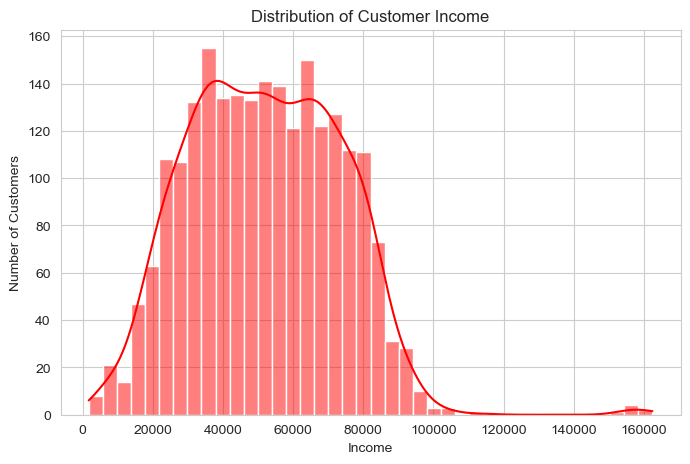

In [26]:
# Step 4 - Chart 1 — Income distribution

plt.figure(figsize = (8,5))
sns.histplot(df_viz['Income'], bins=40, kde=True, color='red')
plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()

# Step 4 - Chart 1 - Income distribution

**Insight:** Income is right-skewed — most customers earn between 25,000–75,000, with a long tail of higher earners.

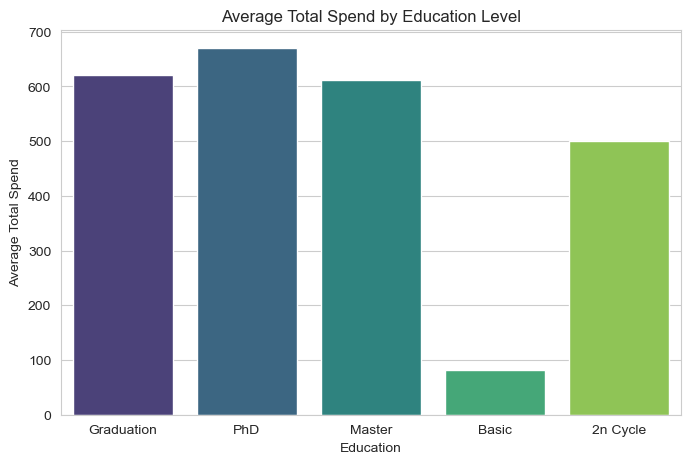

Education
PhD           669.975258
Graduation    619.898846
Master        611.781081
2n Cycle      501.034826
Basic          81.796296
Name: Total_Spend, dtype: float64

In [7]:
# Step 5 - Chart 2 — Average spend by education level

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Education', y='Total_Spend', estimator='mean', errorbar=None,
            hue='Education', palette='viridis', legend=False)
plt.title("Average Total Spend by Education Level")
plt.ylabel("Average Total Spend")
plt.show()

df.groupby('Education')['Total_Spend'].mean().sort_values(ascending=False)

# Step 5 - Chart 2 - Average spend by education level

**Insight:** Basic-education customers spend dramatically less (~82) than every other group (600–670 range).

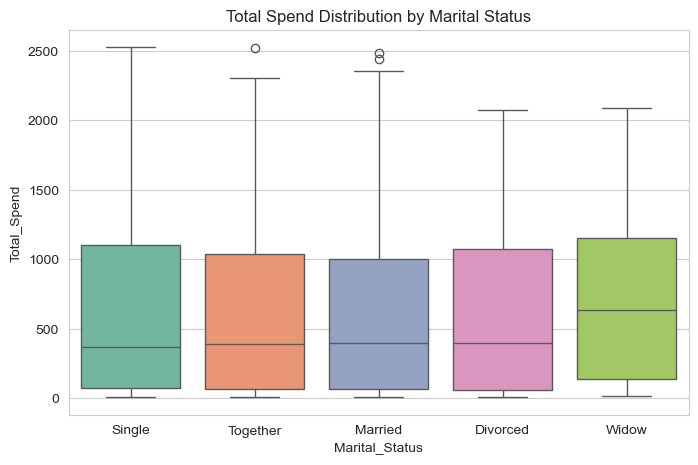

In [34]:
# Step 6 - Chart 3 — Spend by marital status

plt.figure(figsize = (8,5))
sns.boxplot(data=df, x='Marital_Status', y='Total_Spend', hue= 'Marital_Status', palette='Set2', legend=False)
plt.title("Total Spend Distribution by Marital Status")
plt.show()

# Step 6 - Chart 3 - Spend by marital status

**Insight:** Widow customers show a noticeably higher median spend despite being the smallest group.

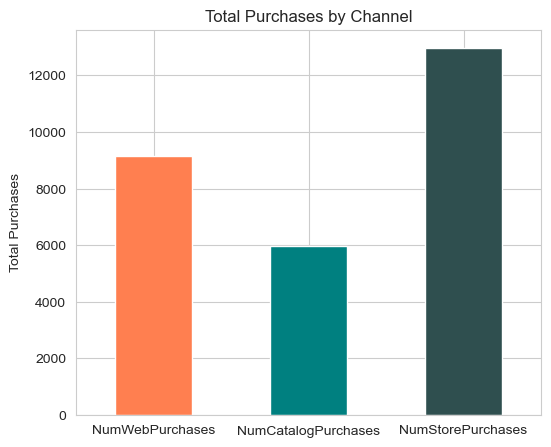

NumWebPurchases         9143
NumCatalogPurchases     5956
NumStorePurchases      12962
dtype: int64


In [13]:
# Step 7 - Chart 4 — Purchases by channel

channel_totals = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum()
plt.figure(figsize=(6,5))
channel_totals.plot(kind='bar', color=['coral', 'teal', 'darkslategray'])
plt.title("Total Purchases by Channel")
plt.ylabel("Total Purchases")
plt.xticks(rotation=0)
plt.show()

print(channel_totals)

# Step 7 - Chart 4 - Purchases by channel

**Insight:** Store purchases dominate, ahead of web and catalog.

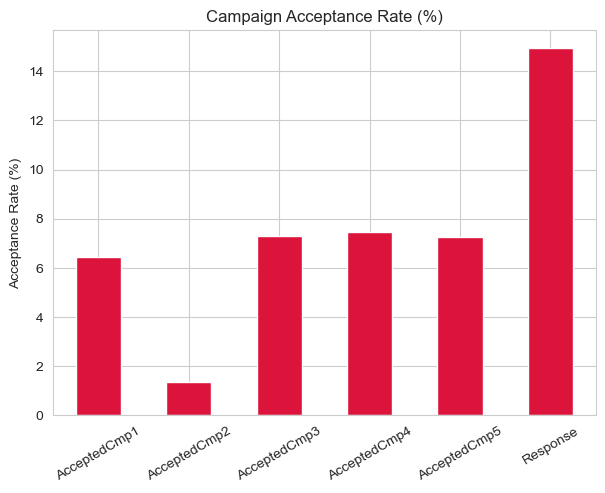

AcceptedCmp1     6.44
AcceptedCmp2     1.34
AcceptedCmp3     7.29
AcceptedCmp4     7.47
AcceptedCmp5     7.24
Response        14.93
dtype: float64


In [17]:
# Step 8 - Chart 5 — Campaign acceptance rates

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
acceptance_rates = df[campaign_cols].mean() * 100

plt.figure(figsize=(7,5))
acceptance_rates.plot(kind= "bar", color = "crimson")
plt.title("Campaign Acceptance Rate (%)")
plt.ylabel("Acceptance Rate (%)")
plt.xticks(rotation = 30)
plt.show()

print(acceptance_rates.round(2))

# Step 8 - Chart 5 - Campaign acceptance rates

**Insight:** The most recent campaign ('Response') hit ~15% acceptance — roughly double every earlier campaign.

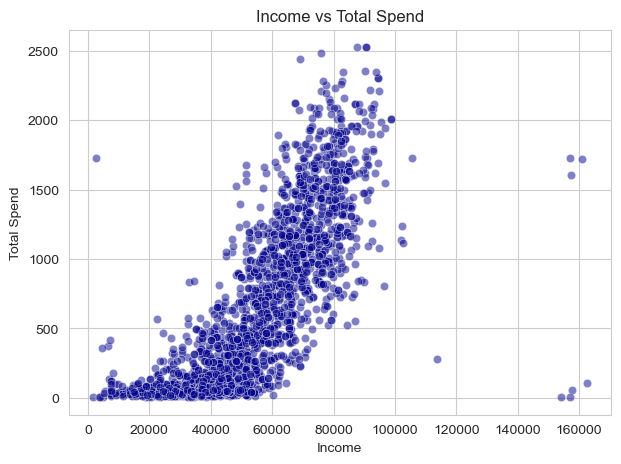

In [18]:
# Step 9: Chart 6 — Income vs. total spend

plt.figure(figsize = (7,5))
sns.scatterplot(data = df_viz, x ='Income', y = 'Total_Spend', alpha = 0.5, color = "darkblue" )
plt.title("Income vs Total Spend")
plt.xlabel("Income")
plt.ylabel("Total Spend")
plt.show()


# Step 9: Chart 6 - Income vs. total spend

**Insight:** Positive correlation overall, but a segment of mid/high earners spend surprisingly little relative to income.